In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 折线图

#### Series图表

<Axes: >

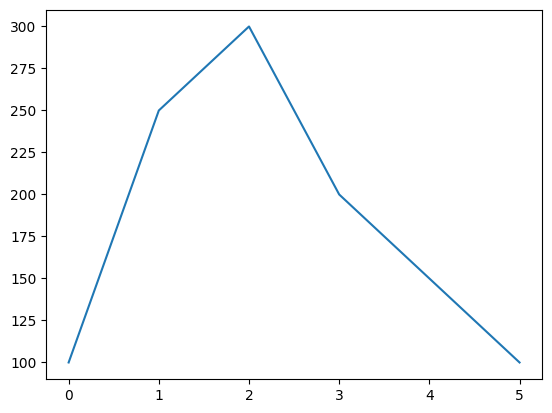

In [51]:
s = pd.Series([100, 250, 300, 200, 150, 100])
s
s.plot()

- 正弦曲线

<Axes: >

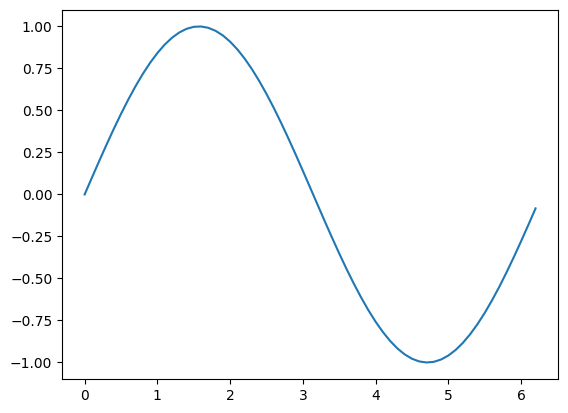

In [52]:
# sin曲线
x = np.arange(0, 2*np.pi, 0.1)
x

y = np.sin(x)

s = pd.Series(y, x)
s

s.plot()

### DataFrame 图表
- 图例的位置可能会随着数据的不同而不同

In [53]:
data = np.random.randint(50, 100, size=(5, 6))
index = ['1st', '2nd', '3th', '4th', '5th']
columns = ['Jeff', 'Jack', 'Rose', 'Lucy', 'Lily', 'Bob']

df = pd.DataFrame(data, index, columns)
df

,Jeff,Jack,Rose,Lucy,Lily,Bob
1st,95,81,64,86,88,66
2nd,89,94,56,89,53,95
3th,80,95,67,77,52,60
4th,69,78,67,92,58,81
5th,51,83,61,69,76,56


<Axes: >

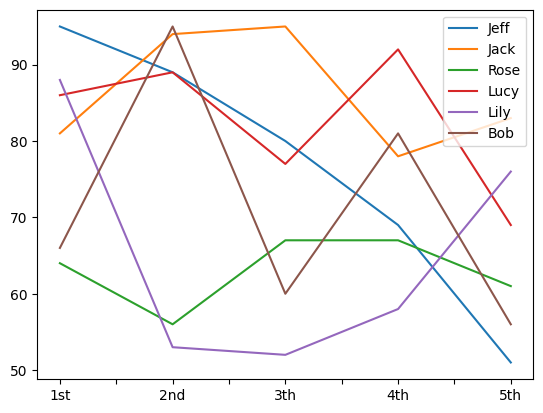

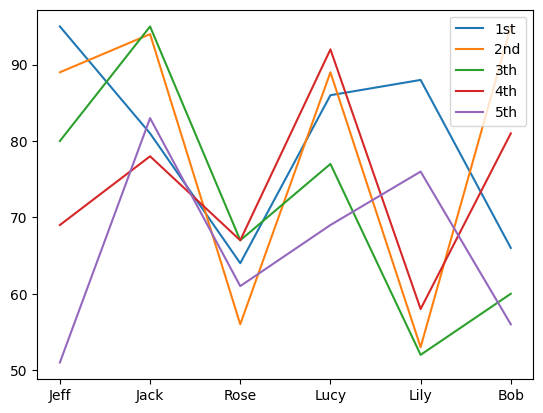

In [54]:
# 每一列一根线
df.plot()

# 每一行一根线
df.T.plot()

### 条形图和柱状图

Series柱状图实例，kind='bar/barh'

<Axes: >

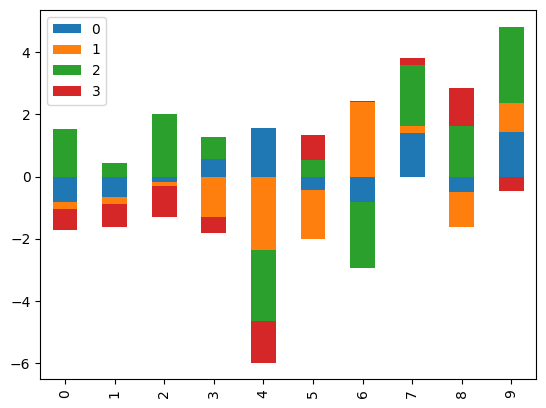

In [55]:
df = pd.DataFrame(np.random.randn(10, 4))
# df.plot(kind = 'bar') # 第一种方式
# df.plot(kind='barh') # 第二种方式
df.plot.bar(stacked=True) # 堆叠

<Axes: >

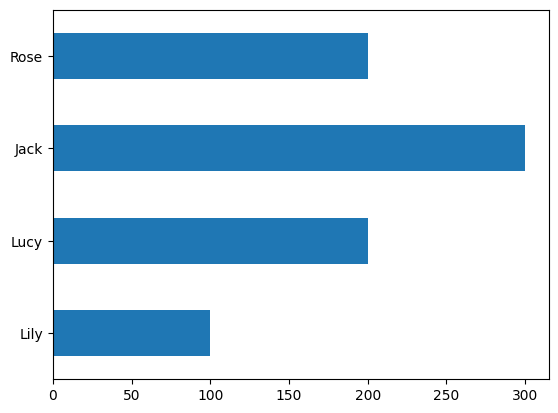

In [56]:
'''
Author: WangGuojian 1085844536@qq.com
Date: 2024-08-31 12:38:00
LastEditTime: 2024-08-31 13:02:10
LastEditors: WangGuojian 1085844536@qq.com
FilePath: \demod:\Developer\WGJ\VSCode_WorkSpace\Python\Pandas\代码\11_Pandas绘图.ipynb
Description:
'''
s = pd.Series([100, 200, 300, 200])
s.index = ['Lily', 'Lucy', 'Jack', 'Rose']
s.plot(kind='barh')

# kind: Literal['line', 'bar', 'barh', 'hist', 'box', 'kde', 'density', 'area', 'pie', 'scatter', 'hexbin']

DataFrame柱状图实例

In [57]:
data = np.random.randint(0, 100, size=(4, 3))
index = list('ABCD')
columns = ['Python', 'C', 'Java']

df = pd.DataFrame(data, index=index, columns=columns)
df

,Python,C,Java
A,63,68,34
B,83,64,88
C,73,78,31
D,16,66,12


<Axes: >

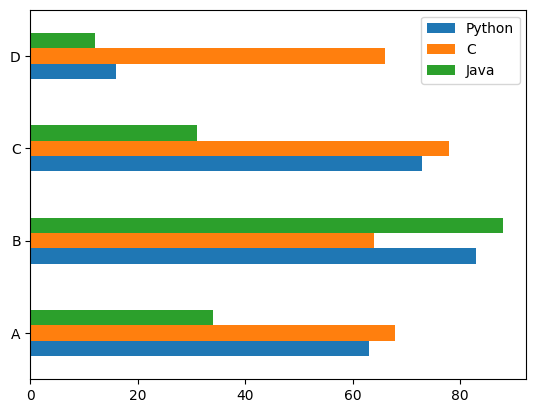

In [58]:
df.plot(kind='barh')

#### 聚会规模可视化项目:
- 读取文件tipsksv，查看每天各种聚会规模的比例求和 
- df.sum()，注意灵活使用axis
- df.div(): 获取数dataframe和其他元素的浮点除法

In [59]:
tips = pd.read_csv('data/tips.csv')
tips

,day,1,2,3,4,5,6
0,Fri,1,16,1,1,0,0
1,Stat,2,53,18,13,1,0
2,Sun,0,39,15,18,3,1
3,Thur,1,48,4,5,1,3


把 day 作为索引

In [60]:
tips2 = tips.set_index('day')
tips2

,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Stat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [61]:
day_sum = tips2.sum(axis=1)
day_sum

day
Fri     19
Stat    87
Sun     76
Thur    62
dtype: int64

In [62]:
tips3 = tips2.div(day_sum, axis=0)
tips3

,1,2,3,4,5,6
day,,,,,,
Fri,0.052632,0.842105,0.052632,0.052632,0.000000,0.000000
Stat,0.022989,0.609195,0.206897,0.149425,0.011494,0.000000
Sun,0.000000,0.513158,0.197368,0.236842,0.039474,0.013158
Thur,0.016129,0.774194,0.064516,0.080645,0.016129,0.048387


<Axes: xlabel='day'>

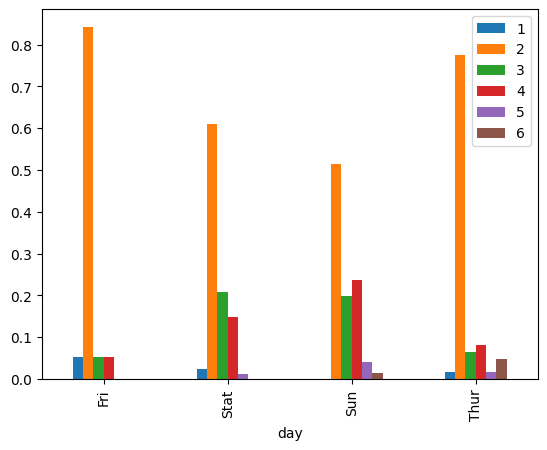

In [63]:
tips3.plot(kind='bar')

### 直方图
rondom生成随机数百分比直方图，调用hist方法
- 柱高表示数据的频数，柱宽表示各组数据的组距
- 参数bins可以设置直方图方柱的个数上限，越大柱宽越小，数据分组越细致
- 设置density参数为True，可以把频数转换为概率

<Axes: ylabel='Frequency'>

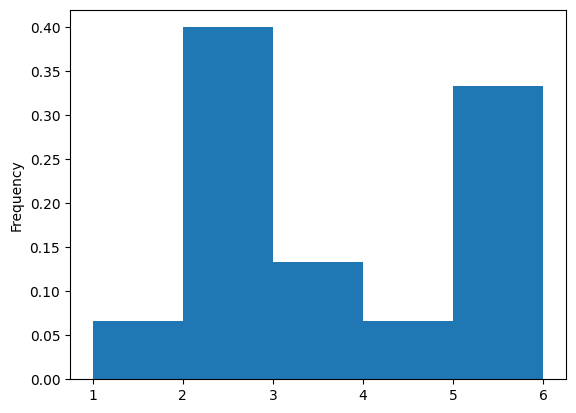

In [64]:
s = pd.Series([1,2,2,2,2,2,2,3,3,4,5,5,5,6,6])

s.plot(kind='hist', bins=5, density=True)

kde图:核密度估计，用于弥补直方图由于参数bins设置的不合理导致的精度缺失问题

<Axes: ylabel='Density'>

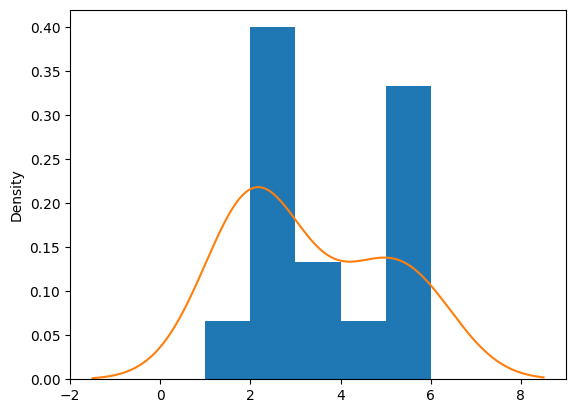

In [67]:
s.plot(kind='hist', bins=5, density=True)

s.plot(kind='kde')

### 饼图

array([<Axes: ylabel='Python'>, <Axes: ylabel='Java'>], dtype=object)

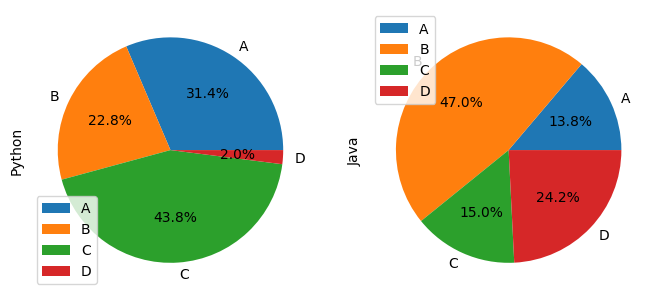

In [74]:
df = pd.DataFrame(np.random.rand(4, 2), index=list('ABCD'), columns=['Python', 'Java'])

df
# 画饼图
# df['Python'].plot(kind='pie', autopct='%.1f%%')

#
df.plot.pie(subplots=True, figsize=(8, 8), autopct='%.1f%%')

### 散点图
- 散点图是观察两个一维数据数列之间的关系的有效方法,DataFrame对象可用

In [77]:
data = np.random.normal(size=(1000, 2))
data

df = pd.DataFrame(data, columns=['A', 'B'])
df.head()

,A,B
0,0.366838,0.556728
1,0.415845,-2.316470
2,-1.407876,0.511253
3,0.107840,1.592351
4,-0.378331,0.563976


<Axes: xlabel='A', ylabel='B'>

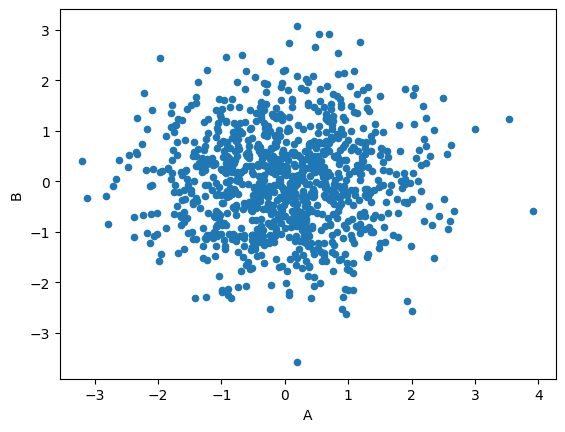

In [80]:
# df.plot(kind='scatter', x='A', y='B')

df.plot.scatter(x='A', y='B')

### 面积图

<Axes: >

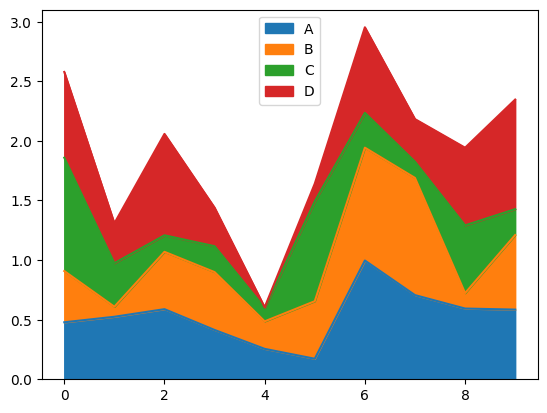

In [86]:
df = pd.DataFrame(np.random.rand(10, 4), columns=list('ABCD'))
df

# df.plot(kind='area')
df.plot.area(stacked=True)

### 箱型图

<Axes: >

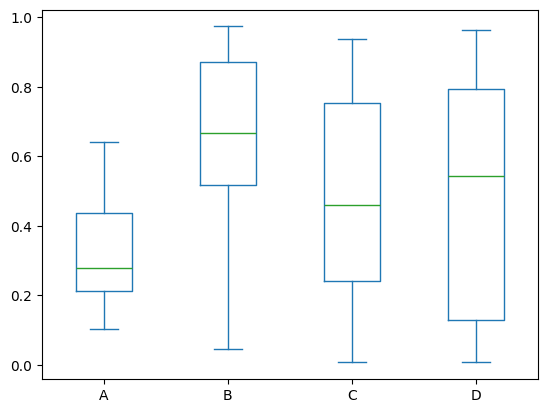

In [88]:
df = pd.DataFrame(np.random.rand(10, 4), columns=list('ABCD'))
df

# df.plot(kind='box')
df.plot.box()

#最大值
#75%
# 50%
# 25%
# 最小值
# 圆点:表式异常值，离群点